# Unsupervised learning for Dementia detection
In this notebook you will try to apply unsupervised learning using autoencoders on PET images, and you will see how the latent space automatically clusters different kinds of dementia and also demographic features

### Imports, GPU setup

In [1]:
!pip install nibabel


[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import nibabel as nib
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

2025-05-19 14:16:31.517683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 14:16:31.532982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-19 14:16:31.546698: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-19 14:16:31.549757: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 14:16:31.559608: I tensorflow/core/platform/cpu_feature_guar

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  # Restrict TensorFlow to only allocate 1GB of memory on the first GPU
  try:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=12*1024)])
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Virtual devices must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1747664193.922582   91371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747664193.935065   91371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747664193.935097   91371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747664193.938424   91371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747664193.938460   91371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

# Read the patient DB

In [4]:
patDB = pd.read_csv('demographics.csv')
patDB.head()

,Age,fName,SexN,Class
0,59,HC/subj-cond_1x1.hdr,F,HC
1,40,HC/subj-cond_2x1.hdr,F,HC
2,28,HC/subj-cond_3x1.hdr,F,HC
3,42,HC/subj-cond_4x1.hdr,F,HC
4,42,HC/subj-cond_5x1.hdr,F,HC


## Split in test-train
This is not necessary! Latent space is learning features automatically, therefore it's not seeing the data to be predicted. However, a small validation dataset might help us in recognizing when the training of the model has converged

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
# Read a sample image to get information about image shape
hT = nib.load('HC/subj-cond_100x1.hdr')
immTest = hT.get_fdata(dtype=np.float32)

In [7]:
baseDir = '/tf/mine/'
trainDB,testDB = train_test_split(patDB,test_size=.2,random_state=42)
trainDB['Class'].value_counts(),testDB['Class'].value_counts()

(Class
 HC       92
 DLB      29
 AD       23
 bvFTD    22
 Name: count, dtype: int64,
 Class
 HC       20
 bvFTD    10
 AD        7
 DLB       5
 Name: count, dtype: int64)

### Read the data and store them in a vector
Read the data. We will force them in np.float32 and not float64.
We will use the format (len(trainDB), Nx,Ny,Nz)

In [8]:
trainVect = np.zeros((len(trainDB),)+immTest.shape,dtype=np.float32)
pIdx=0
for _,sub in trainDB.iterrows():
  #  print(pIdx,end=' ')
    trainVect[pIdx,:,:,:] = nib.load(os.path.join(baseDir,sub['fName'])).get_fdata(dtype=np.float32)
    pIdx+=1

pIdx=0
testVect = np.zeros((len(testDB),)+immTest.shape,dtype=np.float32)
for _,sub in testDB.iterrows():
    testVect[pIdx,:,:,:] = nib.load(os.path.join(baseDir,sub['fName'])).get_fdata(dtype=np.float32)
    pIdx+=1

### Normalize data
Read a mask and use it to normalize the intensity of the data

Note that, when using neural networks, potentially *any* scaling works. *Probably* min-max scaling makes the network the hardest to learn the data

In [9]:
maskHead = nib.load(os.path.join(baseDir,'masks','explicit_mask.nii'))
maskImm = maskHead.get_fdata(dtype=np.float32)>0.5

In [10]:
def normImm (immVect,mask):
    
    for pIdx in range(immVect.shape[0]):       
        tempImm = immVect[pIdx,:,:,:]*mask        
        immVect[pIdx,:,:,:] = tempImm/np.nanmean(tempImm[mask])
    return immVect

In [11]:
trainVect = normImm(trainVect,maskImm)
testVect = normImm(testVect,maskImm)

### Crop and reshape data

Images have a weird shape, with odd numbers, due to some historical factors. Here we will crop/pad them so they are close to 2^N shape. Otherwise downsampling won't work

We will also remove the 5 first cerebellar slices, so that Nz has 64 slices and not 69

In [12]:
def padCropTransposeImm (immVect__):
    immVect__ = np.pad(immVect__[:,:,:,:-5],((0,0),(8,9),(1,0),(0,0)))
    return immVect__

In [13]:
trainVect = padCropTransposeImm(trainVect)
testVect = padCropTransposeImm(testVect)

# Build a very small autoencoder

Our images are 3D. However they have 8 mm smoothing and 2 mm pixels. We can use different shapes for encoder and decoder

So here we can just use 2 Conv3D layers with strides=2 and very few channels, until we're at 8 mm pixels. Then we will reshape the data in 2DxNchannels, "mixing" channels and z-slices, letting the network mixing up the 2.

Then we impose the bottleneck in a fully connected layer (without activation!!)

Then, in the decoder, we reshape the data first in 2D and then 3D with a similar filosophy.

In [19]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D,Conv3DTranspose, MaxPooling3D, MaxPooling2D, BatchNormalization, UpSampling3D
from tensorflow.keras.layers import Flatten, Dense, Reshape, LeakyReLU, Conv2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model

def AE_conv2D(input_size=(96, 96,64, 1)):
    inputs = Input(input_size)
    
    # Downsampling path
    conv1 = Conv3D(4, 3,strides=2, activation='relu', padding='same')(inputs) #48,48,32    4 mm
    conv2 = Conv3D(8, 3,strides=2, activation='relu', padding='same')(conv1) #24,24,16     8 mm pixels
    conv2 = Conv3D(4,1,activation='relu',padding='same')(conv2)      #1x1x1 kernel: convolve only along the channel axis to reduce dimensionality!
    conv2 = Reshape((24,24,64))(conv2) # Reshape to 2D
    conv2 = Conv2D(32, 3, activation='relu', padding='same')(conv2) #24,24,16
    conv2 = Conv2D(32, 3, activation='relu', padding='same')(conv2) #24,24,16
    pool2 = MaxPooling2D(pool_size=(2,2))(conv2) #12,12
    conv3 = Conv2D(64, 3, activation='relu', padding='same')(pool2) #12,12
    conv3 = Conv2D(64, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2,2))(conv3) # 6 6
    conv4 = Conv2D(64, 3, activation='relu', padding='same')(pool3) #6*6*32
    
    x = Flatten() (conv4)   # Reshape flattening
    encoded = Dense(32)(x) # Fully connected
    x = Reshape((1, 1, 32))(encoded) # Reshape in 1x1 images.
    # Using ConvXDTranspose allows us to get images of the shape we want for each channel
    x = Conv2DTranspose(128,(6,6),activation=LeakyReLU(),padding='valid')(x)
    # Upsampling path
    up3 = UpSampling2D(size=(2, 2))(x) #12,12
    conv5 = Conv2D(64, 3, activation=LeakyReLU(), padding='same')(up3)
    conv5 = Conv2D(64, 3, activation=LeakyReLU(), padding='same')(conv5)

    up2 = UpSampling2D(size=(2, 2))(conv5) #24,24
    conv6 = Conv2D(32, 3, activation=LeakyReLU(), padding='same')(up2)
    conv6 = Conv2D(32, 3, activation=LeakyReLU(), padding='same')(conv6)
    conv6 = Conv2D(16,1, activation=LeakyReLU(),padding='same')(conv6)
    conv6 = Reshape((24,24,16,1))(conv6) # Reshape for 3D

    up1 = UpSampling3D(size=(2, 2,2))(conv6) #48,48,32 # 4 mm
    conv7 = Conv3D(16, 3, activation=LeakyReLU(), padding='same')(up1)
    x = UpSampling3D(size=(2,2,2))(conv7) #96,96,64 # 2 mm
    x = Conv3D(16, 3, activation=LeakyReLU(), padding='same')(x)
   
    outputs = Conv3D(1, 1)(x) # merge and use no activation
    
    model = Model(inputs, outputs)
    return model

In [20]:
myModel = AE_conv2D()
from tensorflow.keras.optimizers import Adam

 Take a look at the model. Notice how is has only 200 k parameters

In [21]:
myModel.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 48, 48, 32, 4)  │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 24, 24, 16, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 24, 24, 16, 4)  │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 6, 6, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 16)     │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 24, 24, 16, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 488,781 (1.86 MB)

 Trainable params: 488,781 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

(run it a couple of times with different batch size and number of epochs)

In [32]:

optim= Adam(learning_rate=3e-5)
myModel.compile(optimizer=optim,loss=tf.keras.losses.MeanSquaredError())

In [34]:
fitHist = myModel.fit(trainVect,trainVect,validation_data=(testVect,testVect),shuffle=True,batch_size=8,epochs=300)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.0033 - val_loss: 0.0039
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0028 - val_loss: 0.0039
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 10/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 11/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 12/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/ste

## Training history
We can see that we get down to a very small error. However, the validation loss stops decreasing so we can stop

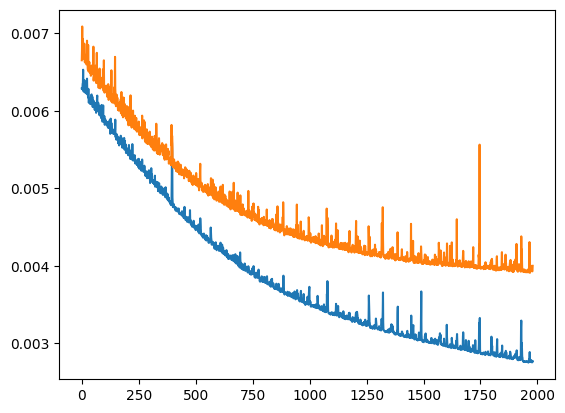

In [30]:
# History with 2e-4
plt.plot(fitHist.history['loss'][20:])
plt.plot(fitHist.history['val_loss'][20:])

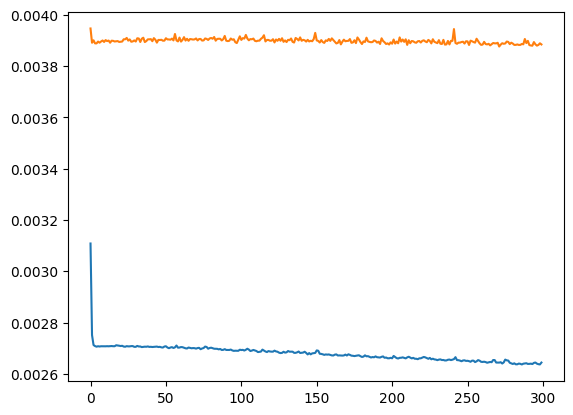

In [52]:
# 2nd training with 5e-5
plt.plot(fitHist.history['loss'][:])
plt.plot(fitHist.history['val_loss'][:])

## Show some auto-encoded images

The quality, especially given the very low number of parameters used, is very high

For the same reasons we have seen in denoising networls, the representation learned is generally smoother

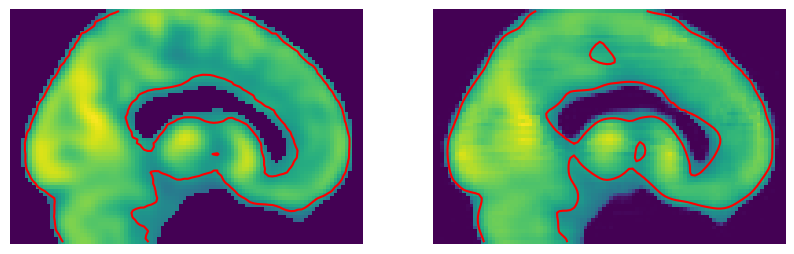

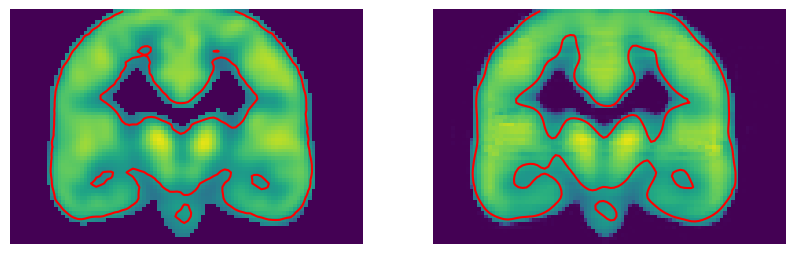

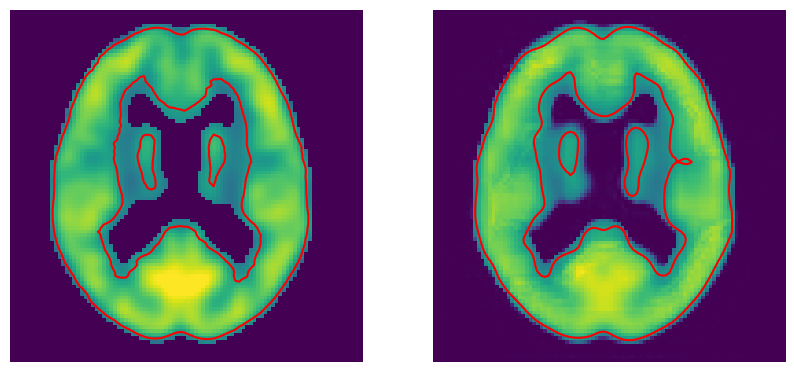

In [36]:
#immTest = adImmVect[:,:,:,0]
randIdx = np.random.randint(len(testVect)-1)
rI = myModel(testVect[randIdx:(randIdx+2),:,:,:])
rI = np.squeeze(np.array(rI))
for dimIdx in range(3):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    plt.imshow(np.flip(testVect[randIdx,:,:,:].take(immTest.shape[dimIdx]//2,axis=dimIdx).T,axis=0),vmin=0,vmax=1.5)
    plt.contour(np.flip(rI[0,:,:,:].take(immTest.shape[dimIdx]//2,axis=dimIdx).T,axis=0),[0.8],colors='red')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(np.flip(rI[0,:,:,:].take(immTest.shape[dimIdx]//2,axis=dimIdx).T,axis=0),vmin=0,vmax=1.5)
  #  plt.colorbar()
    plt.contour(np.flip(testVect[randIdx,:,:,:].take(immTest.shape[dimIdx]//2,axis=dimIdx).T,axis=0),[0.8],colors='red')
    plt.axis('off')    

# Analyze the latent space
Let's see what the model has learned

To do this, we need to extract the numbers in output from the fully connected layer (the "latent space"), we do this creating a new keras model

In [38]:
featModel = Model(inputs=myModel.input,outputs=myModel.get_layer('dense_1').output)

In [39]:
def generate_batches(X, batch_size):
    for i in range(0, len(X), batch_size):
        yield X[i:i + batch_size]

In [40]:
# get the predi
trainV = []
for batch in generate_batches(trainVect,16):
    feats = featModel(batch)
    trainV.extend(feats)
testV = []
for batch in generate_batches(testVect,16):
    feats = featModel(batch)
    testV.extend(feats)    

W0000 00:00:1747666669.581815   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.709170   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.742704   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.760170   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.774919   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.900563   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.903697   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.906446   91371 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1747666669.909073   91371 gp

In [41]:
trainV = np.array(trainV)
testV = np.array(testV)

## Test predictive efficiency

Apply on the extracted features the most basic models we know

This is because we hypotize that in the latent space the features are already directly representative of the factors we're interested in

In [42]:
Class_train = trainDB['Class']  # First categorical column (4 classes)
Sex_train = trainDB['SexN']  # Second categorical column (binary)
Age_train = trainDB['Age']# Scalar column

Class_test = testDB['Class']  # First categorical column (4 classes)
Sex_test = testDB['SexN']  # Second categorical column (binary)
Age_test = testDB['Age']

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(trainV)
X_test = scaler.transform(testV)

In [45]:
# Random forest for multi-class classification
model_cat1 = RandomForestClassifier()
model_cat1.fit(X_train, Class_train)
y_cat1_pred = model_cat1.predict(X_test)

print("First Categorical Column (4 classes):")
print("Accuracy:", accuracy_score(Class_test, y_cat1_pred))
print("Classification Report:\n", classification_report(Class_test, y_cat1_pred))
confM = confusion_matrix(Class_test,y_cat1_pred)

First Categorical Column (4 classes):
Accuracy: 0.8095238095238095
Classification Report:
               precision    recall  f1-score   support

          AD       0.71      0.71      0.71         7
         DLB       0.71      1.00      0.83         5
          HC       0.90      0.90      0.90        20
       bvFTD       0.75      0.60      0.67        10

    accuracy                           0.81        42
   macro avg       0.77      0.80      0.78        42
weighted avg       0.81      0.81      0.81        42



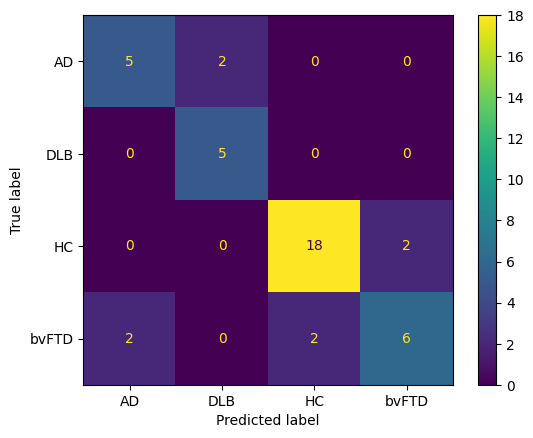

In [46]:
cmDisp= ConfusionMatrixDisplay(confusion_matrix=confM,display_labels=['AD','DLB','HC','bvFTD'])
cmDisp.plot()


In [47]:
y_cat1_pred = model_cat1.predict(X_train)

print("First Categorical Column (4 classes):")
print("Accuracy:", accuracy_score(Class_train, y_cat1_pred))
print("Classification Report:\n", classification_report(Class_train, y_cat1_pred))
confM = confusion_matrix(Class_train,y_cat1_pred)

First Categorical Column (4 classes):
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

          AD       1.00      1.00      1.00        23
         DLB       1.00      1.00      1.00        29
          HC       1.00      1.00      1.00        92
       bvFTD       1.00      1.00      1.00        22

    accuracy                           1.00       166
   macro avg       1.00      1.00      1.00       166
weighted avg       1.00      1.00      1.00       166



Second Categorical Column (binary):
Accuracy: 0.6428571428571429
Classification Report:
               precision    recall  f1-score   support

           F       0.56      0.53      0.55        17
           M       0.69      0.72      0.71        25

    accuracy                           0.64        42
   macro avg       0.63      0.62      0.63        42
weighted avg       0.64      0.64      0.64        42



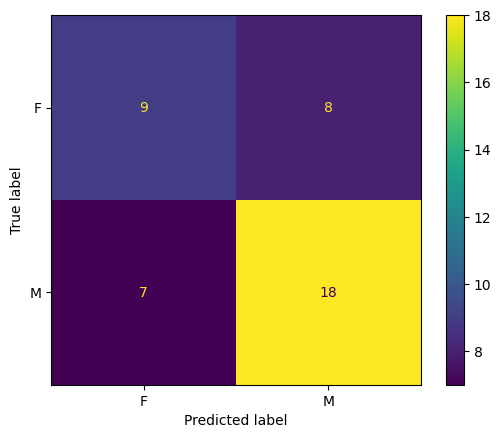

In [48]:
# Logisti regression for binary classification
model_cat2 = LogisticRegression()
model_cat2.fit(X_train, Sex_train)
y_cat2_pred = model_cat2.predict(X_test)

print("Second Categorical Column (binary):")
print("Accuracy:", accuracy_score(Sex_test, y_cat2_pred))
print("Classification Report:\n", classification_report(Sex_test, y_cat2_pred))
confMS = confusion_matrix(Sex_test,y_cat2_pred)
cmDispS= ConfusionMatrixDisplay(confusion_matrix=confMS,display_labels=['F','M'])
cmDispS.plot()

In [49]:
model_scalar = RandomForestRegressor()
model_scalar.fit(X_train, Age_train)
y_scalar_pred = model_scalar.predict(X_test)

print("Scalar Column:")
print(f"Mean Squared Error: {mean_squared_error(Age_test, y_scalar_pred):.2f}")
print(f"R^2 Score:{r2_score(Age_test, y_scalar_pred):.2f}")

Scalar Column:
Mean Squared Error: 47.60
R^2 Score:0.17


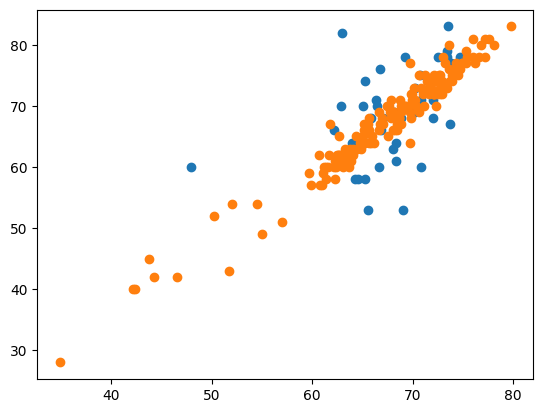

In [50]:
plt.scatter(y_scalar_pred,Age_test)
plt.scatter(model_scalar.predict(X_train),Age_train)